In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [ ]:
df_index = pd.read_csv("economic_index.csv")
# convert all columns to numeric if possible before dropping invalid rows
df_index = df_index.apply(pd.to_numeric, errors='coerce')

In [17]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0.0,2017.0,12.0,2.75,5.3,1464
1,1.0,2017.0,11.0,2.50,5.3,1394
2,2.0,2017.0,10.0,2.50,5.3,1357
3,3.0,2017.0,9.0,2.50,5.3,1293
4,4.0,2017.0,8.0,2.50,5.4,1256


In [18]:
# drop the unnecessary columns
df_index.drop(columns=["Unnamed: 0", "year", "month"], inplace=True)

In [19]:
df_index

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [20]:
##check the null values in the dataset
df_index.isnull().sum()

interest_rate        1
unemployment_rate    1
index_price          0
dtype: int64

In [ ]:
df_index.dropna(inplace=True)
print(df_index.isnull().sum())

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64


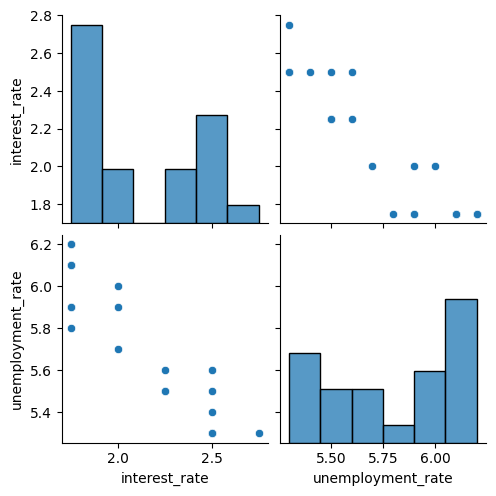

In [25]:
## lets do some visualization of the data to understand the relationship between the features and the target variable.

import seaborn as sns
sns.pairplot(df_index)

In [26]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


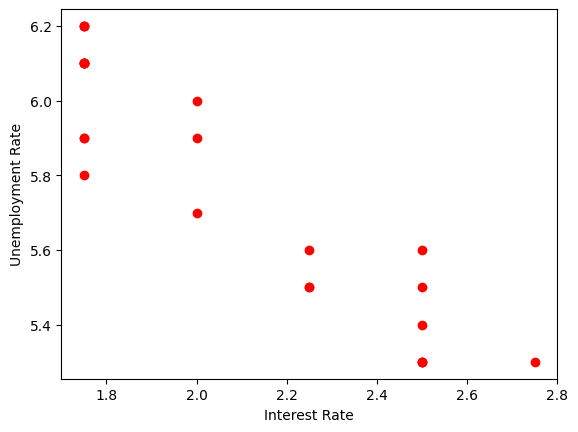

In [29]:
## visulaize the datapoints more closely

plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'],color='red')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')
plt.show()

In [ ]:
##independent and dependent features
X = df_index[['interest_rate', 'unemployment_rate']].apply(pd.to_numeric, errors='coerce')
# X = df_index.iloc[:, :-1]
y = pd.to_numeric(df_index['index_price'], errors='coerce')
# y = df_index.iloc[:, -1]


In [34]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state = 42)

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

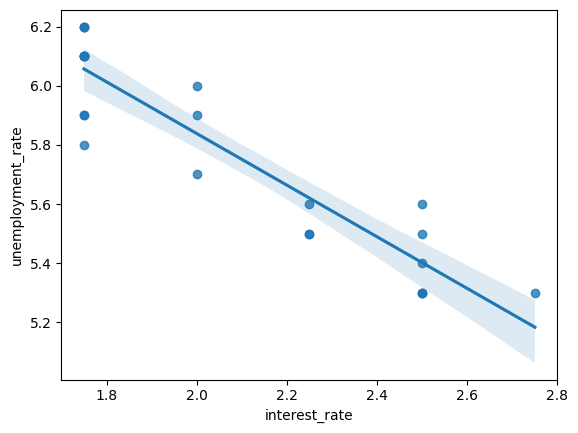

In [40]:
import seaborn as sns

sns.regplot(x=df_index['interest_rate'], y=df_index['unemployment_rate'])

In [44]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [46]:
X_train

array([[-0.90115511,  0.37908503],
       [ 1.31077107, -1.48187786],
       [-0.90115511,  1.30956648],
       [ 1.31077107, -0.55139641],
       [ 1.31077107, -1.48187786],
       [-0.16384638,  0.68924552],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -1.48187786],
       [ 1.31077107, -1.17171738],
       [-0.90115511,  1.30956648],
       [-0.90115511,  0.999406  ],
       [-0.90115511,  0.37908503],
       [-0.90115511,  0.999406  ],
       [ 0.57346234, -0.8615569 ],
       [-0.16384638, -0.24123593],
       [-0.90115511,  0.06892455],
       [-0.90115511,  0.999406  ],
       [ 1.31077107, -0.8615569 ]])

In [48]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [49]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 88.27,-116.26]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1053
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[5.87,1.23]"


In [ ]:
## cross validation to check the performance of the model

from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train,scoring='neg_mean_squared_error', cv=3)

In [52]:
np.mean(scores)

np.float64(-5914.828180162386)

In [53]:
## prediction

y_pred = model.predict(X_test)

In [54]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [55]:
## Performance metrics for the model
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [56]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error : ", mse)
print("Mean Absolute Error : ", mae) 
print("Root Mean Squared Error : ", rmse) 

Mean Squared Error :  8108.567426306604
Mean Absolute Error :  73.80444932337097
Root Mean Squared Error :  90.04758423359621


#### R square and adjusted R square

In [58]:
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred)
print("R-squared Score : ", score)

# display the adjusted R-squared score
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)


R-squared Score :  0.7591371539010257


0.5985619231683761

### Assumptions

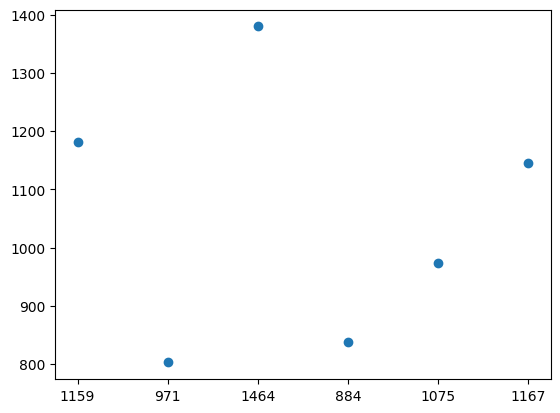

In [59]:
plt.scatter(y_test,y_pred)

In [65]:
y_test = pd.to_numeric(y_test, errors='coerce')
residuals = y_test - y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


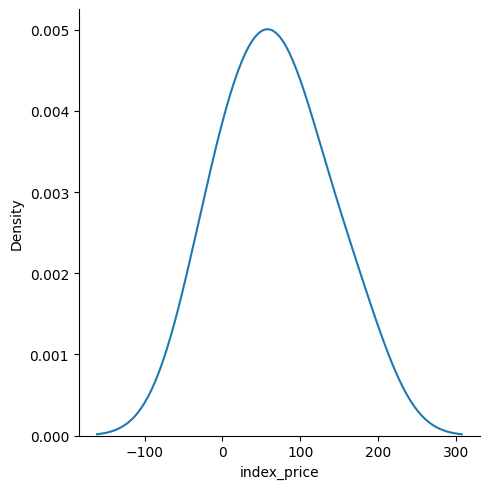

In [66]:
## plot the residuals 
sns.displot(residuals , kind='kde')

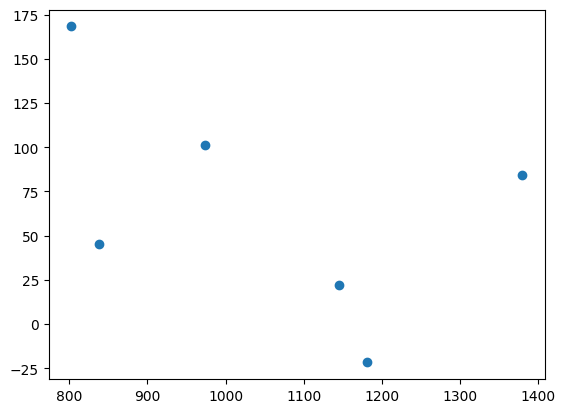

In [67]:
## scatter plot with respect to predictions and residuals
plt.scatter(y_pred,residuals)

In [68]:
## OLS Linear Regression 
import statsmodels.api as sm

In [70]:
# Ensure OLS sees numeric numpy arrays, not object-dtype pandas objects
X_train_ols = sm.add_constant(np.asarray(X_train, dtype=float))
y_train_ols = np.asarray(y_train, dtype=float)

model = sm.OLS(y_train_ols, X_train_ols).fit()


In [72]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.890
Method:                 Least Squares   F-statistic:                     69.88
Date:                Sat, 08 Aug 2026   Prob (F-statistic):           2.50e-08
Time:                        23:41:57   Log-Likelihood:                -100.85
No. Observations:                  18   AIC:                             207.7
Df Residuals:                      15   BIC:                             210.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1053.4444     16.941     62.183      0.000    1017.336    1089.553
x1            88.2728     42.263      2.089      0.054      -1.810     178.355
x2          -116.2572     42.263     -2.751      0.015    -206.340     -26.175
==============================================================================
Omnibus:                        0.598   Durbin-Watson:                   1.804
Prob(Omnibus):                  0.741   Jarque-Bera (JB):                0.567
Skew:                          -0.361   Prob(JB):                        0.753
Kurtosis:                       2.517   Cond. No.                         4.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [78]:
print(model.params) # Print the estimated parameters of the model

[1053.44444444   88.27275507 -116.25716066]
